In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

plt.rcParams['figure.figsize'] = (12, 6)
plt.rcParams['axes.spines.top'] = False
plt.rcParams['axes.spines.right'] = False
sns.set_palette('Set2')


apps = pd.read_csv('../output/playstore_clean.csv')
print("Data loaded:", apps.shape)

Data loaded: (9659, 17)


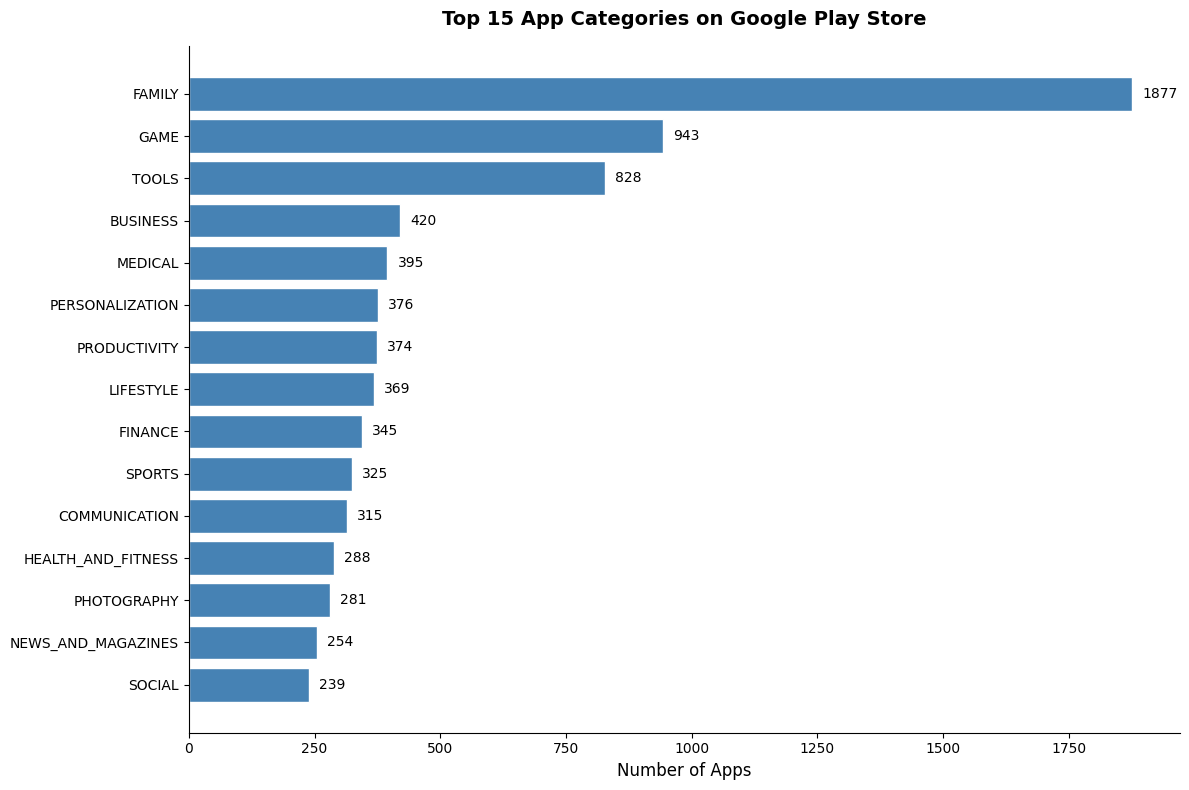

Finding: FAMILY and GAME dominate the Play Store with the highest number of apps.


In [3]:
plt.figure(figsize=(12, 8))
category_counts = apps['Category'].value_counts().head(15)
bars = plt.barh(category_counts.index, category_counts.values, color='steelblue', edgecolor='white')
# Add value labels inside bars
for bar, val in zip(bars, category_counts.values):
    plt.text(val + 20, bar.get_y() + bar.get_height()/2,
             str(val), va='center', fontsize=10)
plt.xlabel('Number of Apps', fontsize=12)
plt.title('Top 15 App Categories on Google Play Store', fontsize=14, fontweight='bold', pad=15)
plt.gca().invert_yaxis()
plt.tight_layout()
plt.savefig('../images/chart1_categories.png', dpi=150, bbox_inches='tight')
plt.show()
print("Finding: FAMILY and GAME dominate the Play Store with the highest number of apps.")

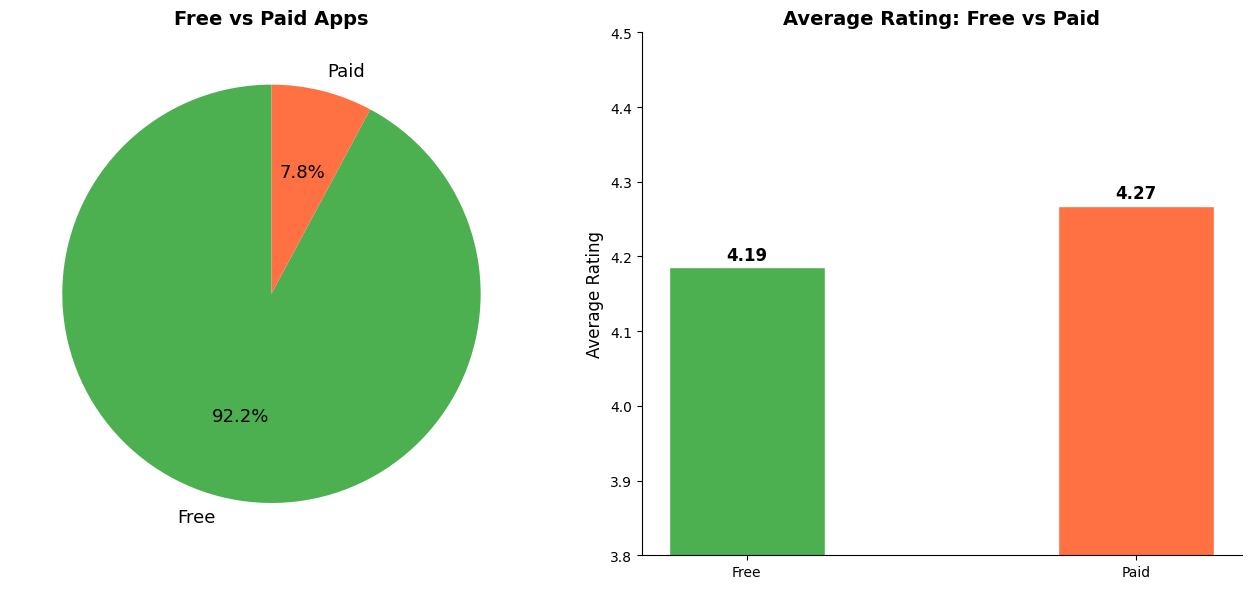

Finding: 93% of apps are free. Paid apps have a slightly higher avg rating (4.27 vs 4.19).


In [4]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(13, 6))

type_counts = apps['Type'].value_counts()
colors = ['#4CAF50', '#FF7043']
ax1.pie(type_counts.values, labels=type_counts.index,
        autopct='%1.1f%%', colors=colors, startangle=90,
        textprops={'fontsize': 13})
ax1.set_title('Free vs Paid Apps', fontsize=14, fontweight='bold')


avg_rating = apps.groupby('Type')['Rating'].mean()
bars = ax2.bar(avg_rating.index, avg_rating.values, color=colors, width=0.4, edgecolor='white')
ax2.set_ylim(3.8, 4.5)
ax2.set_ylabel('Average Rating', fontsize=12)
ax2.set_title('Average Rating: Free vs Paid', fontsize=14, fontweight='bold')
for bar, val in zip(bars, avg_rating.values):
    ax2.text(bar.get_x() + bar.get_width()/2, val + 0.01,
             f'{val:.2f}', ha='center', fontsize=12,fontweight='bold')

plt.tight_layout()
plt.savefig('../images/chart2_free_vs_paid.png', dpi=150, bbox_inches='tight')
plt.show()
print("Finding: 93% of apps are free. Paid apps have a slightly higher avg rating (4.27 vs 4.19).")

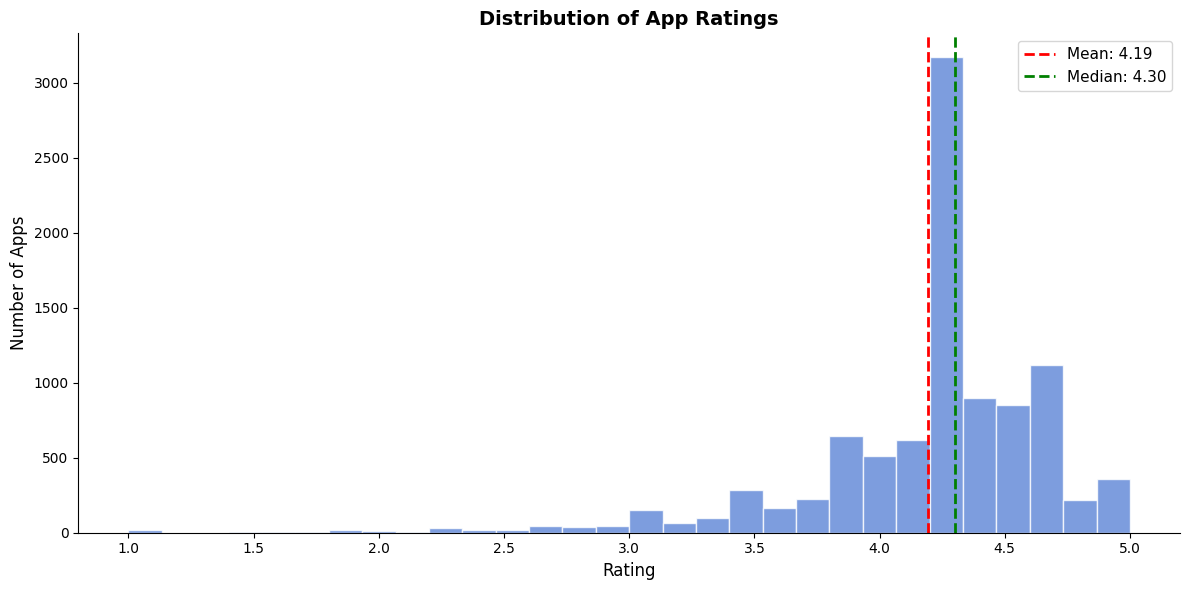

Finding: Ratings are left-skewed — most apps have a rating above 4.0.


In [5]:
plt.figure(figsize=(12, 6))

plt.hist(apps['Rating'], bins=30, color='#5C85D6', edgecolor='white', alpha=0.8)
plt.axvline(apps['Rating'].mean(), color='red', linestyle='--', linewidth=2,
            label=f'Mean: {apps["Rating"].mean():.2f}')
plt.axvline(apps['Rating'].median(), color='green', linestyle='--', linewidth=2,
            label=f'Median: {apps["Rating"].median():.2f}')

plt.xlabel('Rating', fontsize=12)
plt.ylabel('Number of Apps', fontsize=12)
plt.title('Distribution of App Ratings', fontsize=14, fontweight='bold')
plt.legend(fontsize=11)
plt.tight_layout()
plt.savefig('../images/chart3_rating_dist.png', dpi=150, bbox_inches='tight')
plt.show()
print("Finding: Ratings are left-skewed — most apps have a rating above 4.0.")

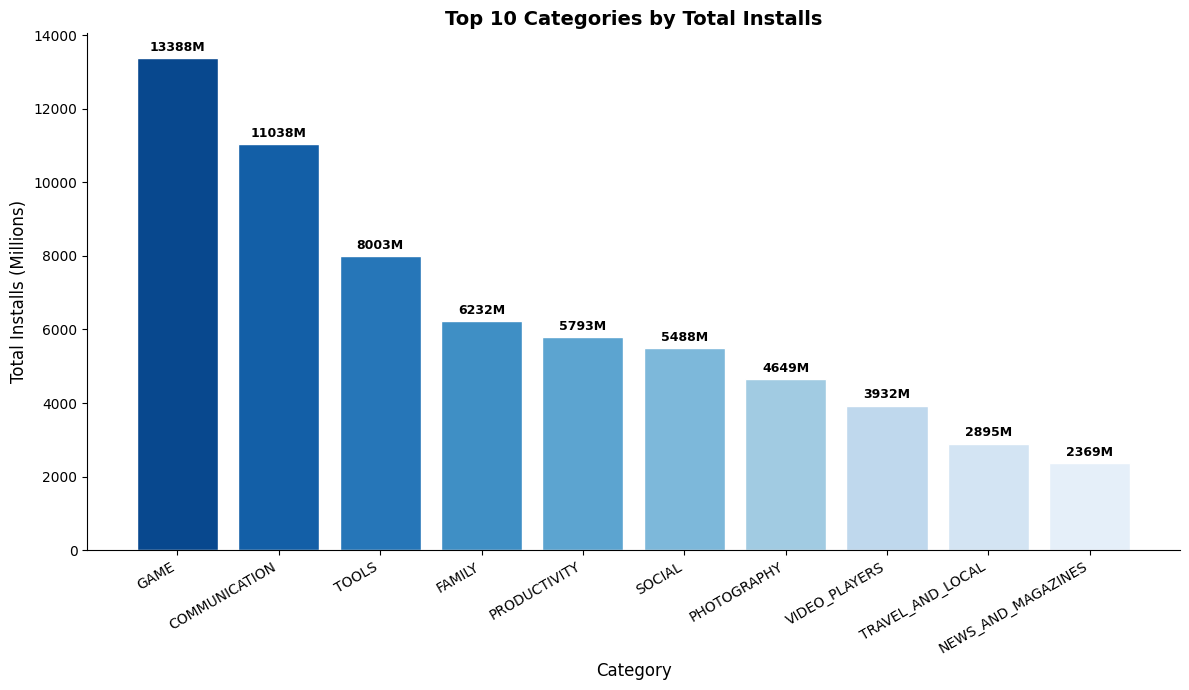

Finding: COMMUNICATION and SOCIAL apps dominate total installs (WhatsApp, Facebook effect).


In [6]:
plt.figure(figsize=(12, 7))
install_by_cat = apps.groupby('Category')['Installs'].sum().sort_values(ascending=False).head(10)
install_millions = install_by_cat / 1_000_000  
colors = sns.color_palette('Blues_r', 10)
bars = plt.bar(install_by_cat.index, install_millions.values, color=colors, edgecolor='white')

for bar, val in zip(bars, install_millions.values):
    plt.text(bar.get_x() + bar.get_width()/2, val + 200,
             f'{val:.0f}M', ha='center', fontsize=9, fontweight='bold')

plt.xlabel('Category', fontsize=12)
plt.ylabel('Total Installs (Millions)', fontsize=12)
plt.title('Top 10 Categories by Total Installs', fontsize=14, fontweight='bold')
plt.xticks(rotation=30, ha='right')
plt.tight_layout()
plt.savefig('../images/chart4_installs_by_category.png', dpi=150, bbox_inches='tight')
plt.show()
print("Finding: COMMUNICATION and SOCIAL apps dominate total installs (WhatsApp, Facebook effect).")

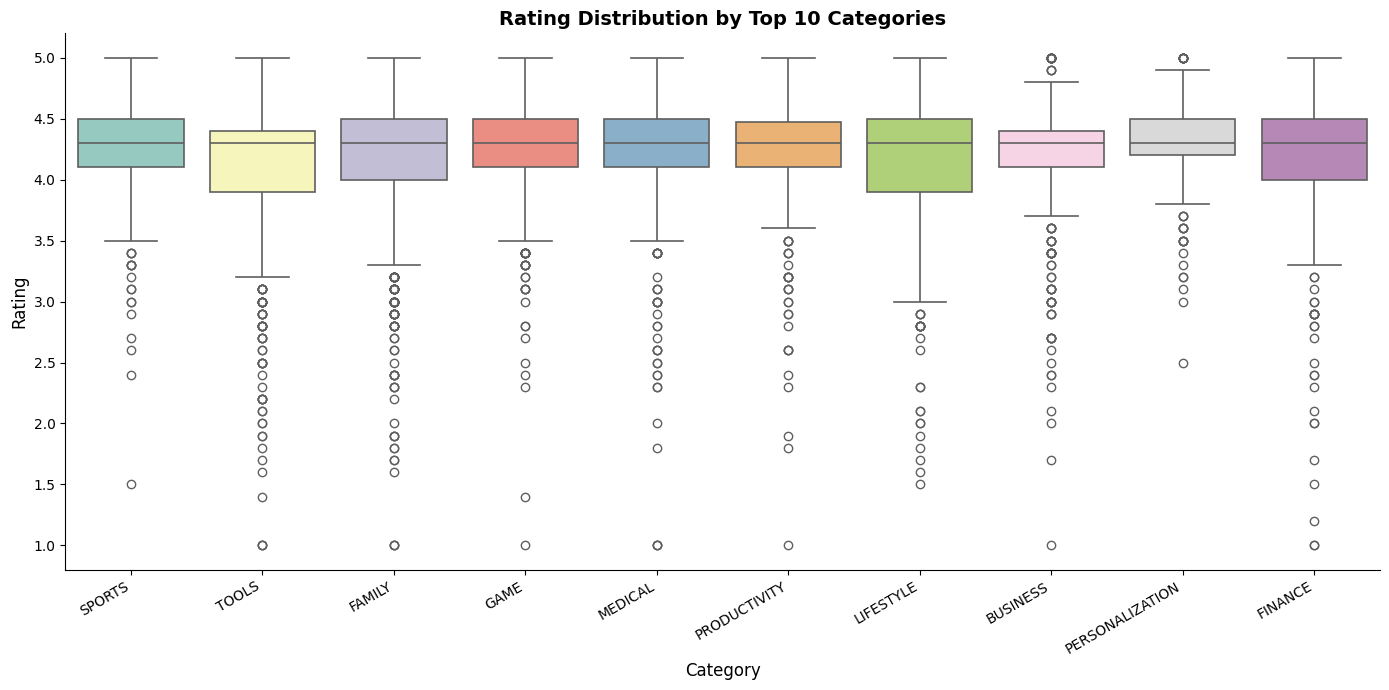

Finding: Most categories have median ratings between 4.0-4.5. GAME has the widest spread.


In [7]:
plt.figure(figsize=(14, 7))
top10_cats = apps['Category'].value_counts().head(10).index
df_top10 = apps[apps['Category'].isin(top10_cats)]

sns.boxplot(data=df_top10, x='Category', y='Rating',
            palette='Set3', linewidth=1.2)

plt.xlabel('Category', fontsize=12)
plt.ylabel('Rating', fontsize=12)
plt.title('Rating Distribution by Top 10 Categories', fontsize=14, fontweight='bold')
plt.xticks(rotation=30, ha='right')
plt.tight_layout()
plt.savefig('../images/chart5_boxplot_rating.png', dpi=150, bbox_inches='tight')
plt.show()
print("Finding: Most categories have median ratings between 4.0-4.5. GAME has the widest spread.")

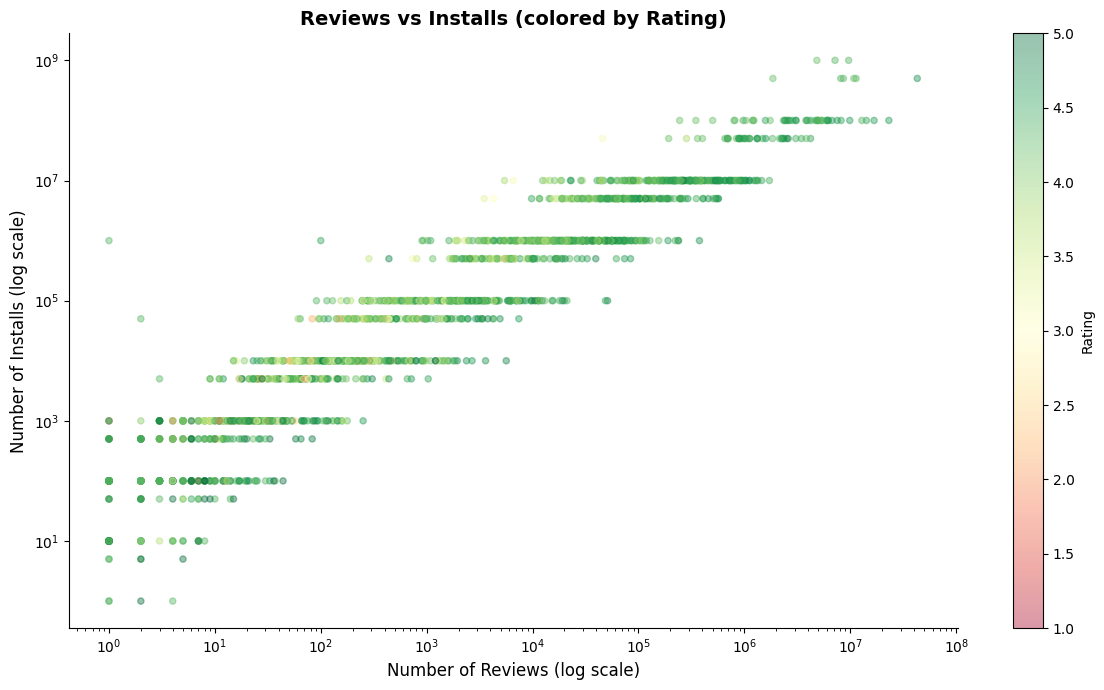

Finding: Strong positive correlation between reviews and installs. Higher-rated apps tend to have more of both.


In [8]:
plt.figure(figsize=(12, 7))

# Use log scale because values span millions
sample = apps[(apps['Installs'] > 0) & (apps['Reviews'] > 0)].sample(2000, random_state=42)

scatter = plt.scatter(sample['Reviews'], sample['Installs'],
                      alpha=0.4, c=sample['Rating'],
                      cmap='RdYlGn', s=20)

plt.colorbar(scatter, label='Rating')
plt.xscale('log')
plt.yscale('log')
plt.xlabel('Number of Reviews (log scale)', fontsize=12)
plt.ylabel('Number of Installs (log scale)', fontsize=12)
plt.title('Reviews vs Installs (colored by Rating)', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('../images/chart6_scatter.png', dpi=150, bbox_inches='tight')
plt.show()
print("Finding: Strong positive correlation between reviews and installs. Higher-rated apps tend to have more of both.")

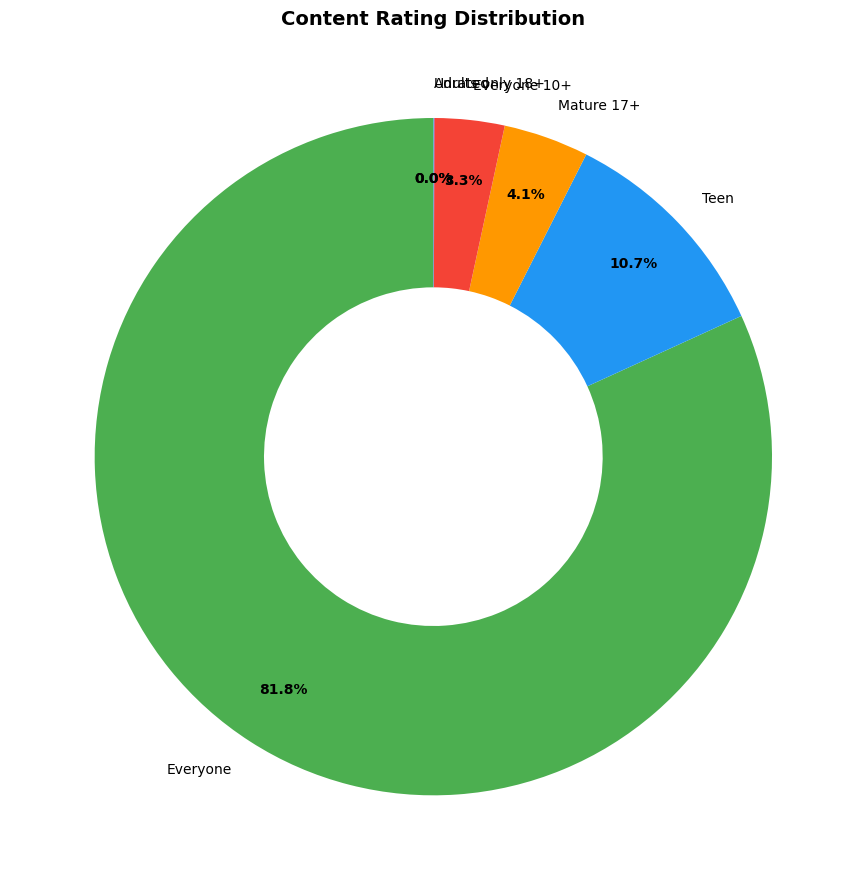

Finding: Over 80% of apps are rated 'Everyone' — the Play Store is family-friendly by design.


In [9]:
plt.figure(figsize=(9, 9))

content_counts = apps['Content Rating'].value_counts()
colors = ['#4CAF50', '#2196F3', '#FF9800', '#F44336', '#9C27B0', '#00BCD4']
wedges, texts, autotexts = plt.pie(
    content_counts.values,
    labels=content_counts.index,
    autopct='%1.1f%%',
    colors=colors[:len(content_counts)],
    startangle=90,
    pctdistance=0.82,
    wedgeprops=dict(width=0.5)   # makes it a donut
)

for autotext in autotexts:
    autotext.set_fontsize(10)
    autotext.set_fontweight('bold')

plt.title('Content Rating Distribution', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('../images/chart7_content_rating.png', dpi=150, bbox_inches='tight')
plt.show()
print("Finding: Over 80% of apps are rated 'Everyone' — the Play Store is family-friendly by design.")

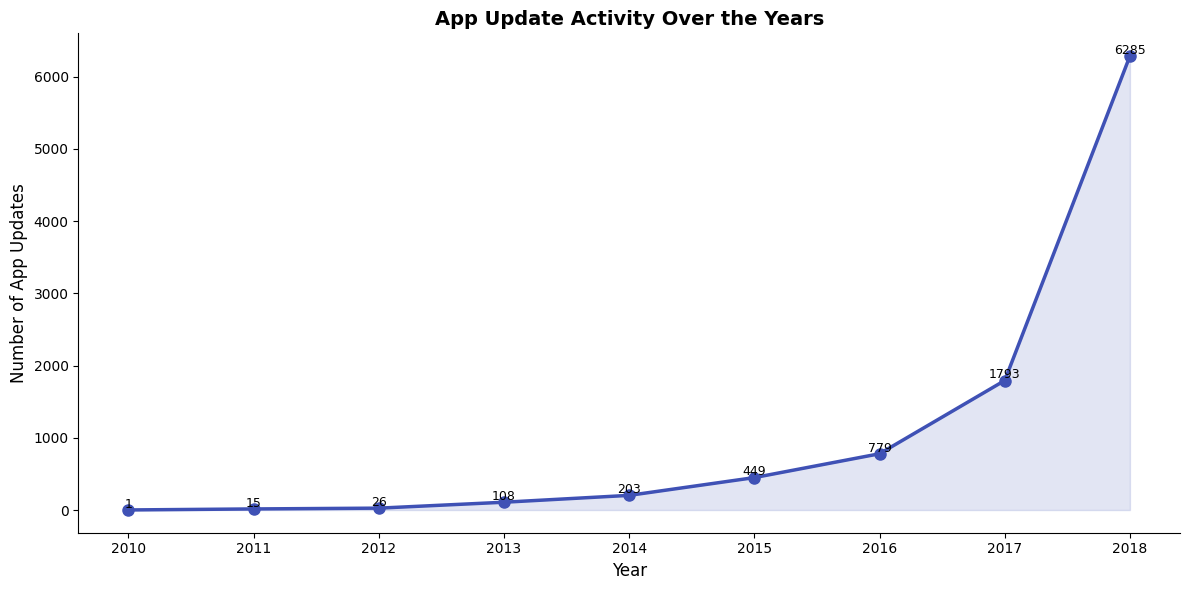

Finding: App updates peaked in 2018, showing the Play Store ecosystem grew rapidly from 2015 onward.


In [12]:
plt.figure(figsize=(12, 6))

update_year = apps['update_year'].value_counts().sort_index()
# Filter reasonable years only
# update_year = update_year[update_year.index.between(2010, 2018)]
update_year = update_year[(update_year.index.to_series().between(2010, 2018))]
plt.plot(update_year.index, update_year.values,
         marker='o', linewidth=2.5, color='#3F51B5', markersize=8)
plt.fill_between(update_year.index, update_year.values, alpha=0.15, color='#3F51B5')
for x, y in zip(update_year.index, update_year.values):
    plt.text(x, y + 30, str(y), ha='center', fontsize=9)
plt.xlabel('Year', fontsize=12)
plt.ylabel('Number of App Updates', fontsize=12)
plt.title('App Update Activity Over the Years', fontsize=14, fontweight='bold')
plt.xticks(update_year.index)
plt.tight_layout()
plt.savefig('../images/chart8_updates_by_year.png', dpi=150, bbox_inches='tight')
plt.show()
print("Finding: App updates peaked in 2018, showing the Play Store ecosystem grew rapidly from 2015 onward.")

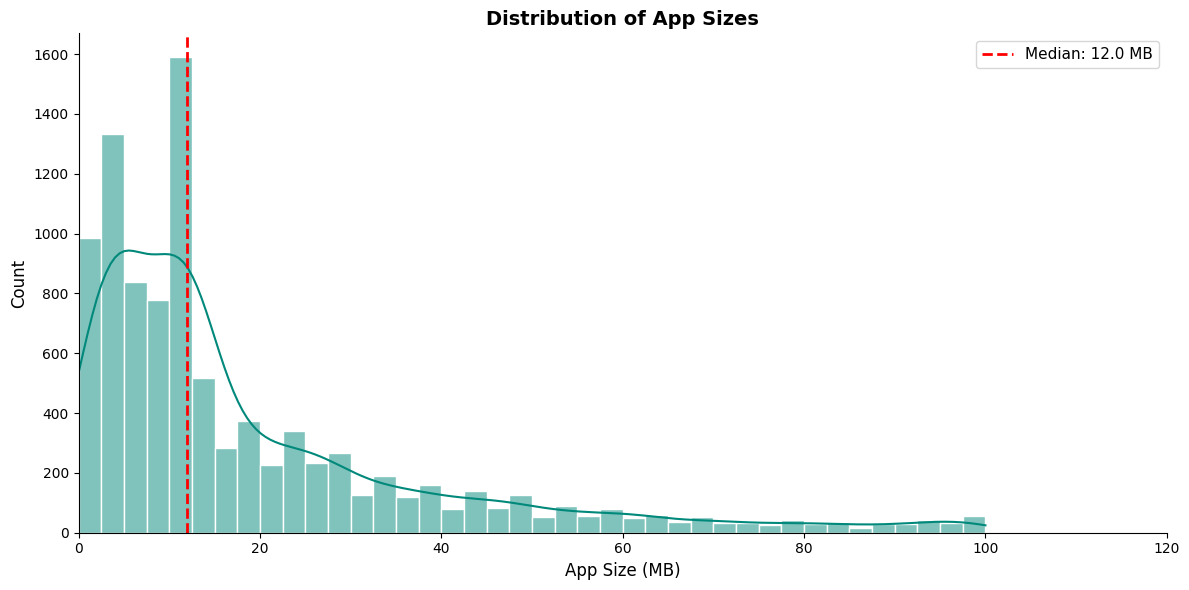

Finding: Most apps are under 30MB. Very large apps (>80MB) are rare — likely games.


In [13]:
plt.figure(figsize=(12, 6))

sns.histplot(apps['Size'].dropna(), bins=40, kde=True,
             color='#00897B', edgecolor='white')

plt.axvline(apps['Size'].median(), color='red', linestyle='--',
            linewidth=2, label=f'Median: {apps["Size"].median():.1f} MB')

plt.xlabel('App Size (MB)', fontsize=12)
plt.ylabel('Count', fontsize=12)
plt.title('Distribution of App Sizes', fontsize=14, fontweight='bold')
plt.legend(fontsize=11)
plt.xlim(0, 120)
plt.tight_layout()
plt.savefig('../images/chart9_size_dist.png', dpi=150, bbox_inches='tight')
plt.show()
print("Finding: Most apps are under 30MB. Very large apps (>80MB) are rare — likely games.")

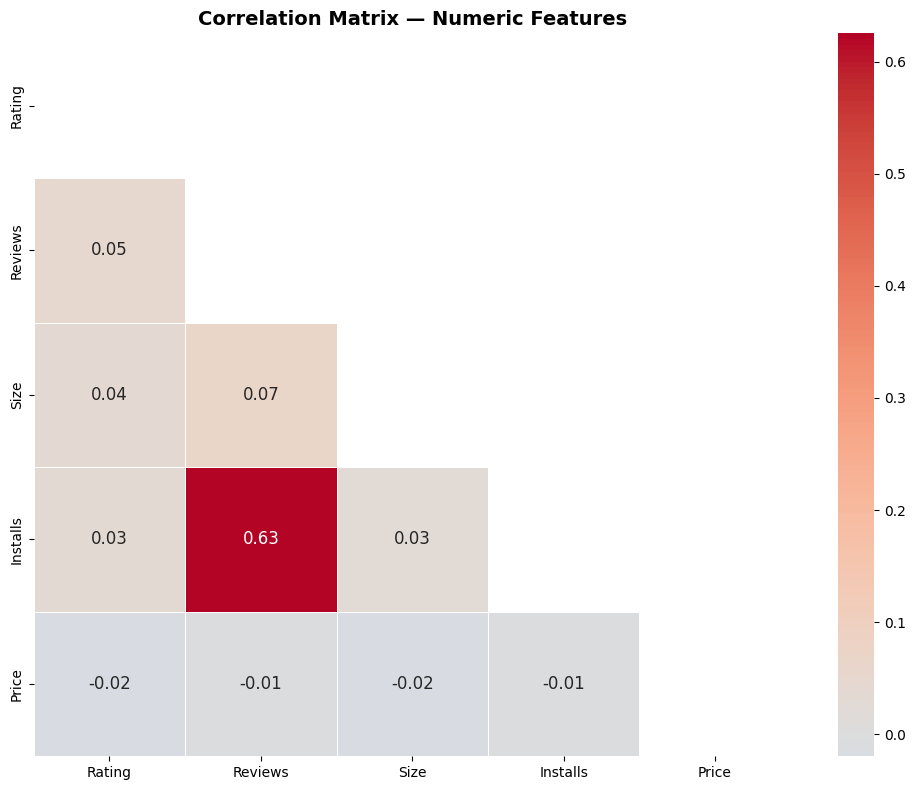

Finding: Reviews and Installs are strongly correlated (0.64). Price has near-zero correlation with Rating.


In [14]:
plt.figure(figsize=(10, 8))

# only numeric columns get selecy
num_cols = ['Rating', 'Reviews', 'Size', 'Installs', 'Price']
corr_matrix = apps[num_cols].corr()
mask = np.triu(np.ones_like(corr_matrix, dtype=bool))  # hide upper triangle

sns.heatmap(corr_matrix, annot=True, fmt='.2f',
            cmap='coolwarm', center=0,
            mask=mask,
            linewidths=0.5,
            annot_kws={'size': 12})

plt.title('Correlation Matrix — Numeric Features', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('../images/chart10_heatmap.png', dpi=150, bbox_inches='tight')
plt.show()
print("Finding: Reviews and Installs are strongly correlated (0.64). Price has near-zero correlation with Rating.")